# Caso aprobacion de tarjetas de crédito

Ign. Mayrling Martínez Flores

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold

In [2]:
mypath = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/australian/australian.dat"

data = pd.read_csv(mypath, sep=" ", header=None)

data.columns = ['A1','A2','A3','A4','A5','A6','A7','A8','A9','A10','A11','A12','A13','A14','class']

print(data.shape)
data.head()

(690, 15)


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,class
0,1,22.08,11.46,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,0,22.67,7.00,2,8,4,0.165,0,0,0,0,2,160,1,0
2,0,29.58,1.75,1,4,4,1.250,0,0,0,1,2,280,1,0
3,0,21.67,11.50,1,5,3,0.000,1,1,11,1,2,0,1,1
4,1,20.17,8.17,2,6,4,1.960,1,1,14,0,2,60,159,1


In [3]:
data['A4'].value_counts()

A4
2    525
1    163
3      2
Name: count, dtype: int64

In [4]:
data['A4'] = data['A4'].map({2:2, 1:0, 3:0})
data['A5'] = data['A5'].map({1:1,2:0,3:3,4:4,5:0,6:6,7:7,8:8,9:9,10:0,11:11,12:0,13:13,14:14})
data['A6'] = data['A6'].map({1:1,2:0,3:0,4:4,5:5,7:0,8:8,9:0})

In [5]:
# Ahora sí, definamos nuestras variables de entrada y de salida, observa que ambas son DataFrames de Pandas:

X = data.iloc[:,:-1]

Y = data.iloc[:,-1]     # También puede ser: data[['class']]

In [6]:
Xtv, Xtest, ytv, ytest = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=1)

print(Xtv.shape, ': dimensión de datos de entrada para entrenamiento y validación')
print(Xtest.shape, ': dimensión de datos de entrada para prueba')

print(ytv.shape, ': dimensión de variable de salida para entrenamiento y validación')
print(ytest.shape, ': dimensión de variable de salida para prueba')

(552, 14) : dimensión de datos de entrada para entrenamiento y validación
(138, 14) : dimensión de datos de entrada para prueba
(552,) : dimensión de variable de salida para entrenamiento y validación
(138,) : dimensión de variable de salida para prueba


In [7]:
ytv.sum() / ytv.shape[0]

np.float64(0.44565217391304346)

In [9]:
# Transformaciones a factores numéricos de entrada:
num_pipeline = Pipeline(steps=[('impMediana', SimpleImputer(strategy='median')),
                               ('escalaNum', MinMaxScaler(feature_range=(1, 2)))])
num_pipeline_nombres = ['A2', 'A3', 'A7', 'A10', 'A13', 'A14']

# Transformaciones a factores categóricos de entrada:
catImp_pipeline = Pipeline(steps=[('impModa', SimpleImputer(strategy='most_frequent'))])
catImp_pipeline_nombres = ['A1', 'A4', 'A5', 'A6', 'A8', 'A9', 'A11', 'A12']

catOHE_pipeline = Pipeline(steps=[('OneHotE', OneHotEncoder(drop='first'))])
catOHE_pipeline_nombres = ['A4', 'A5', 'A6', 'A12']

# Conjuntamos las transformaciones numéricas y categóricas que se estarán aplicando a los datos de entrada:
columnasTransformer = ColumnTransformer(transformers=[('numpipe', num_pipeline, num_pipeline_nombres),
                                                      ('catimp', catImp_pipeline, catImp_pipeline_nombres),
                                                      ('catohe', catOHE_pipeline, catOHE_pipeline_nombres)],
                                        remainder='passthrough')

In [11]:
def get_models():
  modelos = list()
  nombres = list()

  # LR - Regresión Logística:
  modelos.append(LogisticRegression(solver='liblinear'))
  nombres.append('LR')

  # DT - Árbol de Decisión:
  modelos.append(DecisionTreeClassifier())
  nombres.append('DT')

  # MLP - Red Neuronal Artificial / Perceptrón Lineal Multicapa:
  modelos.append(MLPClassifier(hidden_layer_sizes=(30,), max_iter=3000))
  nombres.append('MLP')

  # SVM - Máquina de Vector Soporte:
  modelos.append(SVC(gamma='scale'))
  nombres.append('SVM')

  # kNN - k-Vecinos más cercanos:
  modelos.append(KNeighborsClassifier())
  nombres.append('kNN')

  return modelos, nombres

In [12]:
modelos, nombres = get_models()  # cargamos los modelos a comparar
resultados = list()

for i in range(len(modelos)):

  pipeline = Pipeline(steps=[('ct',columnasTransformer),('m',modelos[i])])

  cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=0)
  scores = cross_val_score(pipeline, Xtv, np.ravel(ytv), scoring='accuracy', cv=cv)


  resultados.append(scores)
  print('>> %s: %.3f (%.3f)' % (nombres[i], np.mean(scores), np.std(scores)))

>> LR: 0.861 (0.039)
>> DT: 0.808 (0.056)
>> MLP: 0.839 (0.039)
>> SVM: 0.850 (0.041)
>> kNN: 0.791 (0.040)


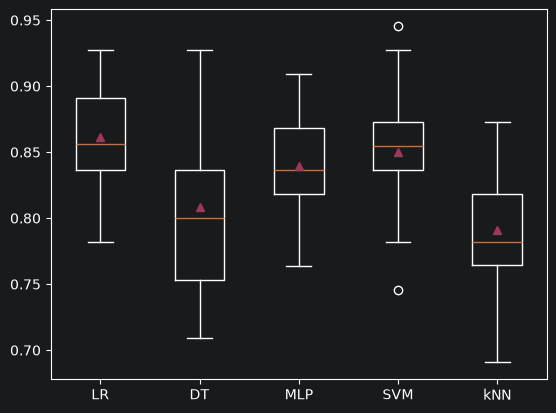

In [13]:
plt.boxplot(resultados, tick_labels=nombres, showmeans=True)
plt.show()

# Regresión logistica con regularización

In [14]:
#from pandas.core.common import random_state

def get_modelsRegs():
    modelos, nombres = list(), list()

    # LR - sin regularización:
    modelos.append(LogisticRegression(C=np.inf, solver='lbfgs', max_iter=2000, random_state=1))
    nombres.append('LR')

    # Lasso:
    modelos.append(LogisticRegression(l1_ratio=1, solver='liblinear', max_iter=2000, C=1., random_state=1))
    nombres.append('LASSO')

    # Ridge:
    modelos.append(LogisticRegression(l1_ratio=0, solver='liblinear', max_iter=2000, C=10.01, random_state=1))
    nombres.append('RIDGE')

    # Elastic-Net:
    modelos.append(LogisticRegression(l1_ratio=0.5, solver='saga', max_iter=4000, C=1., random_state=1))
    nombres.append('EN')

    return modelos, nombres

>> LR 0.867 (0.051)
>> LASSO 0.867 (0.046)
>> RIDGE 0.869 (0.048)
>> EN 0.863 (0.048)


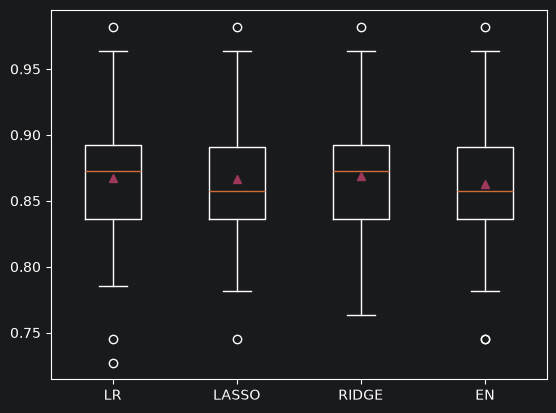

In [15]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

modelos, nombres = get_modelsRegs()
resultados = list()

for i in range(len(modelos)):

    pipeline = Pipeline(steps=[('ct', columnasTransformer), ('m', modelos[i])])

    cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=5, random_state=8)
    scores = cross_val_score(pipeline, Xtv, np.ravel(ytv), scoring='accuracy', cv=cv)

    resultados.append(scores)
    print('>> %s %.3f (%.3f)' % (nombres[i], np.mean(scores), np.std(scores)))

plt.boxplot(resultados, tick_labels=nombres, showmeans=True)
plt.show()